# Красно-синие шары: эмпирическая проверка классической вероятности

Моделирование связи частотного и классического определения вероятности.

В урне находятся 3 красных и 2 синих шара. После каждого извлечения шар возвращается обратно, поэтому вероятность каждого исхода остаётся постоянной.

Классическая вероятность извлечения красного шара:

$$P(красный)=\frac{3}{5}=0.6.$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Количество красных и синих шаров
red = 3
blue = 2

# Классическая вероятность извлечения красного шара
p_red = red / (red + blue)

# Количество экспериментов
n = 10_000

print(f"Красных шаров: {red}")
print(f"Синих шаров: {blue}")
print(f"Всего шаров: {red + blue}")
print(f"Классическая вероятность красного шара: {p_red:.2f}")

Красных шаров: 3
Синих шаров: 2
Всего шаров: 5
Классическая вероятность красного шара: 0.60


## Имитация эксперимента

Каждый эксперимент моделируется случайным образом. Вероятность получить красный шар равна 0.6.

После каждого опыта вычисляется накопленная относительная частота появления красного шара:

$$W_n = \frac{k}{n},$$

где $k$ — количество красных шаров среди первых $n$ экспериментов.

In [4]:
rng = np.random.default_rng(42)

# Моделируем n независимых извлечений с возвращением шара
# True означает, что выпал красный шар
results = rng.random(n) < p_red

# Накопленное количество красных шаров
red_count = np.cumsum(results)

# Номера экспериментов
trials = np.arange(1, n + 1)

# Частотная вероятность на каждом шаге
frequency = red_count / trials

print(f"Красных шаров после {n} экспериментов: {red_count[-1]}")
print(f"Итоговая частотная вероятность: {frequency[-1]:.4f}")
print(f"Отклонение от классической вероятности: {abs(frequency[-1] - p_red):.4f}")

Красных шаров после 10000 экспериментов: 6048
Итоговая частотная вероятность: 0.6048
Отклонение от классической вероятности: 0.0048


## График сходимости

Синяя линия показывает частотную вероятность, полученную в результате моделирования.

Красная пунктирная линия показывает классическую вероятность $P=0.6$.

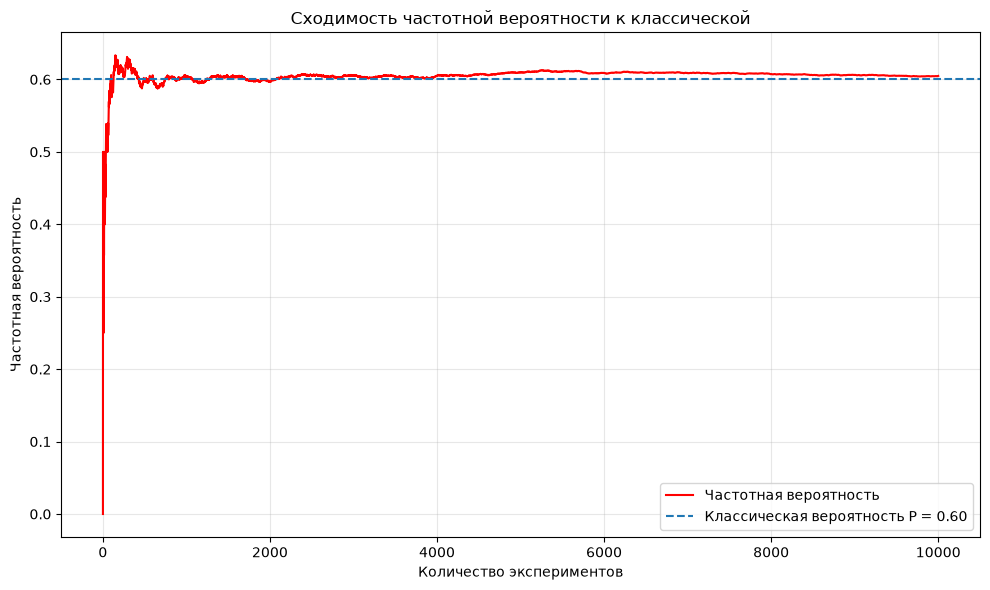

In [4]:
plt.figure(figsize=(10, 6))

plt.plot(
    trials,
    frequency,
    label="Частотная вероятность",
    color='red'
)

plt.axhline(
    p_red,
    linestyle="--",
    label=f"Классическая вероятность P = {p_red:.2f}"
)

plt.xlabel("Количество экспериментов")
plt.ylabel("Частотная вероятность")
plt.title("Сходимость частотной вероятности к классической")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Контрольные значения

Рассмотрим частотную вероятность после разного количества экспериментов.

In [7]:
checkpoints = [10, 50, 100, 500, 1000, 5000, 10000]

print("Опытов | Красных | Частота | Отклонение")
print("-" * 45)

for k in checkpoints:
    count = int(red_count[k - 1])
    freq = count / k
    error = abs(freq - p_red)
    print(f"{k:6d} | {count:8d} | {freq:.4f} | {error:.4f}")

Опытов | Красных | Частота | Отклонение
---------------------------------------------
    10 |        4 | 0.4000 | 0.2000
    50 |       26 | 0.5200 | 0.0800
   100 |       60 | 0.6000 | 0.0000
   500 |      300 | 0.6000 | 0.0000
  1000 |      603 | 0.6030 | 0.0030
  5000 |     3049 | 0.6098 | 0.0098
 10000 |     6048 | 0.6048 | 0.0048


## Вывод

Классическая вероятность извлечения красного шара равна $0.6$. При небольшом количестве экспериментов частотная вероятность может значительно отклоняться от этого значения из-за случайных колебаний.

При увеличении количества экспериментов частотная вероятность колеблется около значения $0.6$ и в среднем приближается к нему. Таким образом, моделирование демонстрирует связь классического и частотного определения вероятности:

$$W_n(A) \rightarrow P(A), \quad n \rightarrow \infty.$$